# **ESPIDAM: Epidemiological Modeling and Deep Reinforcement Learning**
***Authors: Bram Silue, Sebastiaan Weytjens, Prof. dr. Pieter Libin, Prof. dr. Niel Hens.***  
***Acknowledgements: Veronica Biancacci, Alexandra Cimpean.***

### **How to Run**
If you're having trouble running this code on your local machine, please open and run this notebook in Colab:

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/plibin/espidam-dev/blob/main/epi-deep-rl/1_epi_deep_rl_solution.ipynb)

We define some helper code that allows this notebook to run in both local environments and Google Colab:

In [1]:
def is_running_in_colab() -> bool:
    """
    Returns if the code is running inside Google Colab.

    """
    try:
        import google.colab
        return True
    except ImportError:
        return False

### **Introduction**
We will consider the problem of school closures. More specifically, given a particular school closure budget (in weeks), how can we allocate these school closure weeks in an optimal way?

We will look at a simple setting, with many simplifying assumptions, yet by the end of this exercise, we will have the background on how to target epidemiological problems using reinforcement learning.

##### **Model and Markov decision process**

We will use an age-structured SIR ODE model, where we will implement school closures by adjusting the contact matrix (as studied during the practical of the first day of ESPIDAM). We will consider the optimisation with respect to the number of new infections.

To formalize this setting, we consider:

- a state space that directly corresponds to the state space of the epi model  
- a transition function that corresponds to the dynamics of the ODE model  
- actions that correspond to the closure of schools on a weekly basis (i.e., decide every week of the epidemic whether to keep the schools open or close them)  
- a reward function that considers the difference in susceptibles at every time step 
  - $-[(S_a + S_c) - (S’_a + S’_c)]$; as detailed in [1].

### **Dependencies**
First, make sure to install miniconda and the necessary libraries as specified in [`README.md`](README.md). After that, we import the necessary libraries and dependencies as follows:

In [2]:
# Environment and simulation.
if is_running_in_colab():
    import subprocess
    subprocess.run(["pip", "install", "gymnasium"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import NormalizeObservation, NormalizeReward

# Machine learning.
if is_running_in_colab():
    subprocess.run(["pip", "install", "stable-baselines3"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

# Numerical computing.
import numpy as np
from scipy.integrate import odeint

# Plotting.
import matplotlib.pyplot as plt

# Other tools.
import random

# Ignore warnings.
import warnings
warnings.filterwarnings("ignore")

### **Implementation**
We provide you with a function `run_sir_model` in `sir.py` that allows you to simulate the epi model until a given timestep:

In [3]:
# Disease parameters.
disease_params = {
    "beta": 0.02,
    "gamma": 1 / 7,
    "schools_closed": False,
}

seeds = 1
N_c = 3666
N_a = 7334

# Contact matrices.
contact_matrix = [[18, 9], [3, 12]]
contact_matrix_schools_closed = [[0, 5], [2, 8]]


def contacts(i: int, j: int, schools_closed: bool) -> int:
    """
    Returns the number of contacts between age group `i` and `j`
    depending on whether schools are closed.

    Arguments
    ---------
    i              :  Index of the source age class.
    j              :  Index of the target age class.
    schools_closed :  Whether schools are closed.

    Returns
    -------
    Number of contacts between the two age groups.

    """
    if schools_closed:
        return contact_matrix_schools_closed[i][j]
    else:
        return contact_matrix[i][j]


# Transition rates.
def foi(i: list, 
        params: dict, 
        Ns: list, 
        ac_idx: int, 
        acs: int, 
        schools_closed: bool) -> float:
    """
    Calculates the force of infection for a given age class.

    Arguments
    ---------
    i              :  List of infected counts per age class.
    params         :  Disease parameters dictionary.
    Ns             :  Population sizes per age class.
    ac_idx         :  Index of the current age class.
    acs            :  Number of age classes.
    schools_closed :  Whether schools are closed.

    Returns
    -------
    foi_value :  Force of infection experienced by age class `ac_idx`.

    """
    foi_value = 0
    for ac_j in range(acs):
        foi_value += (
            params["beta"]
            * contacts(ac_idx, ac_j, schools_closed)
            * i[ac_j]
            / Ns[ac_j]
        )
    return foi_value


def i_r(params: dict) -> float:
    """
    Returns the I → R transition rate.

    Arguments
    ---------
    params :  Disease parameters.

    Returns
    -------
    The recovery rate.

    """
    return params["gamma"]


def initialise_modelstate(seeds: int, 
                          N_c: int, 
                          N_a: int) -> np.ndarray:
    """
    Initializes the model state for children and adults.

    Arguments
    ---------
    seeds :  Initial number of infected individuals in each group.
    N_c   :  Population size of children.
    N_a   :  Population size of adults.

    Returns
    -------
    model_state :  Initial state as a NumPy array.

    """
    return np.array([N_c - seeds, seeds, 0, N_a - seeds, seeds, 0])


# ODE solver.
def ode_system(y0: np.ndarray, 
               t: float, 
               parameters: dict) -> tuple:
    """
    Defines the system of ODEs for the SIR model with age structure.

    Arguments
    ---------
    y0         :  Current state.
    t          :  Current time (not used explicitly).
    parameters :  Dictionary containing disease parameters and population sizes.

    Returns
    -------
    Tuple of derivatives for each compartment.

    """
    params = parameters["disease_params"]
    Ns = parameters["Ns"]

    s_c, i_c, r_c, s_a, i_a, r_a = y0
    ds_c, di_c, dr_c             = 0, 0, 0
    ds_a, di_a, dr_a             = 0, 0, 0

    # Children.
    ds_c += -foi([i_c, i_a], params, Ns, 0, 2, params["schools_closed"]) * s_c
    di_c += foi([i_c, i_a], params, Ns, 0, 2, params["schools_closed"]) * s_c - i_r(params) * i_c
    dr_c += i_r(params) * i_c

    # Adults.
    ds_a += -foi([i_c, i_a], params, Ns, 1, 2, params["schools_closed"]) * s_a
    di_a += foi([i_c, i_a], params, Ns, 1, 2, params["schools_closed"]) * s_a - i_r(params) * i_a
    dr_a += i_r(params) * i_a

    return ds_c, di_c, dr_c, ds_a, di_a, dr_a


def run_sir_model(model_state: np.ndarray, 
                  end_t: int, 
                  params: dict, 
                  Ns: list) -> np.ndarray:
    """
    Simulates the SIR model using the ODE solver.

    Arguments
    ---------
    model_state :  Initial model state.
    end_t       :  Final time step.
    params      :  Disease parameters.
    Ns          :  Population sizes per age class.

    Returns
    -------
    model_state :  Final model state as a NumPy array.

    """
    all_parameters = {
        "disease_params": params,
        "Ns": Ns,
    }

    y0 = (*model_state,)
    t = np.linspace(0, end_t, end_t)

    ret = odeint(ode_system, y0, t, args=(all_parameters,))
    s_c, i_c, r_c, s_a, i_a, r_a = ret.T

    return np.array([s_c[-1], i_c[-1], r_c[-1], s_a[-1], i_a[-1], r_a[-1]])


If we optimize school closures without any constraints, the reinforcement learning agent has no incentive to limit the number of weeks the schools are closed, while there is clearly an important burden involved in such choices. Ideally, we would tackle this from a multi-criteria perspective (more on that later today), but, for the sake of simplicity, we will consider a budget of school closures.

This means that, if the agent chooses to close schools when the budget is spent, this action will have to be ignored.

### **Implementing the Gymnasium environment**
So, to take the first step, let’s code a gym environment that implements the above modalities.  
Recall that on the second day of ESPIDAM, we studied a simple gym environment [2] that can act as inspiration for your implementation.

We will give you some tips, to give you a head start:

- use a Discrete action space (`gym.spaces.Discrete`)  
- use a Box observation space (`spaces.Box`)  
- no need to implement a `render` function  

In [4]:
class SIREnv(gym.Env):
    """
    A Gym-compatible environment for simulating SIR dynamics with school closure actions.

    Arguments
    ---------
    budget       :  The total number of weeks schools can be closed.
    compartments :  A list of compartment names in the model.
    seeds        :  Initial number of infected individuals per group.
    N_c          :  Population size of children.
    N_a          :  Population size of adults.
    params       :  Model parameters (includes transmission, recovery, etc.).

    """
    def __init__(self, 
                 budget: int, 
                 compartments: list, 
                 seeds: int, 
                 N_c: int, 
                 N_a: int, 
                 params: dict) -> None:
        self.budget = budget
        self.seeds = seeds
        self.N_c = N_c
        self.N_a = N_a
        self.N = N_c + N_a
        self.params = params
        self.compartments = compartments

        # Define action and observation space.
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = spaces.Box(0, max(N_c, N_a), shape=(len(compartments) + 1,), dtype=np.float32)

    def _get_obs(self) -> np.ndarray:
        """
        Returns the current model state, clipped to avoid small negatives.

        Returns
        -------
        A NumPy array of compartment values.

        """
        state = np.maximum(self.model_state, 0)
        return np.append(state, self.used_budget).astype(np.float32)

    def _get_info(self) -> dict:
        """
        Returns auxiliary info about the environment.

        Returns
        -------
        A dictionary containing time step metadata.

        """
        return {
            "t": self._t,
        }

    def reset(self, seed=None, options=None):
        """
        Resets the environment state, budget, and time.

        Arguments
        ---------
        seed    :  Optional random seed.
        options :  Optional Gym API argument (unused).

        Returns
        -------
        obs  :  The initial observation.
        info :  The initial environment metadata.

        """
        super().reset(seed=seed)
        self._t = 0
        self.used_budget = 0
        self.model_state = initialise_modelstate(self.seeds, self.N_c, self.N_a)
        return self._get_obs(), self._get_info()

    def step(self, action: int):
        """
        Takes a step in the environment given an action.

        Arguments
        ---------
        action :  The action to take (0 = no closure, 1 = close schools).

        Returns
        -------
        obs        :  The new observation.
        reward     :  The reward after applying the action.
        terminated :  Whether the episode has ended.
        truncated  :  Always False (truncation not used).
        info       :  Auxiliary environment metadata.

        """
        close_schools = (action == 1)

        # Prevent action if budget is exhausted.
        if self.used_budget >= self.budget:
            close_schools = False

        if close_schools:
            self.used_budget += 1

        self.params["schools_closed"] = close_schools
        end_t = self._get_info()["t"] + 7

        new_model_state = run_sir_model(
            self.model_state, end_t, self.params, [self.N_c, self.N_a]
        )

        _new_s = (
            new_model_state[self.compartments.index("S_c")] +
            new_model_state[self.compartments.index("S_a")]
        )
        _old_s = (
            self.model_state[self.compartments.index("S_c")] +
            self.model_state[self.compartments.index("S_a")]
        )

        self.model_state = new_model_state
        self._t = end_t

        # Reward is negative change in susceptibles = new infections.
        reward     = -(_old_s - _new_s)
        terminated = self._t >= 180

        return self._get_obs(), reward, terminated, False, self._get_info()

def make_sir_env(budget: int, 
                 seeds: int, 
                 N_c: int, 
                 N_a: int, 
                 gamma: float, 
                 beta: float):
    """
    Constructs and registers a Gym environment for the SIR model.

    Arguments
    ---------
    budget :  Total number of school closures allowed.
    seeds  :  Initial number of infected individuals.
    N_c    :  Population size of children.
    N_a    :  Population size of adults.
    gamma  :  Recovery rate.
    beta   :  Transmission rate.

    Returns
    -------
    env :  The configured Gym environment.

    """
    gym.envs.registration.register(
        id="SIREnv-v0",
        entry_point=SIREnv,
        max_episode_steps=300,
    )

    compartments = ["S_c", "I_c", "R_c", "S_a", "I_a", "R_a"]

    params = {
        "beta": beta,                # transmission rate
        "gamma": gamma,              # recovery rate
        "schools_closed": False,     # school closure toggle
    }

    env = gym.make(
        "SIREnv-v0",
        compartments=compartments,
        seeds=seeds,
        budget=budget,
        N_c=N_c,
        N_a=N_a,
        params=params,
    )

    return env

**Test your gym environment!**  
If there are bugs in your gym environment, the agent will learn bogus things. As such, it is *very* important to properly test the environment by interfacing with it via the `step` function, and verify the output of some example policies (i.e., sequences of school closure decisions).

In [5]:
def validate_gym(env: gym.Env,
                 seeds: int,
                 N_c: int,
                 N_a: int,
                 params: dict[str, float],
                 budget: int = 1000) -> None:
    """
    Compares the Gym simulation output to the underlying ODE model over a sequence of random actions.

    Arguments
    ---------
    env    :  The Gym environment.
    seeds  :  Initial number of infected individuals.
    N_c    :  Population size of children.
    N_a    :  Population size of adults.
    params :  Dictionary of model parameters.
    budget :  Maximum number of weeks schools can be closed.

    """
    env.reset()
    actions = [random.choice([True, False]) for _ in range(50)]

    initial_modelstate = initialise_modelstate(seeds, N_c, N_a)

    env_states = [(initial_modelstate[1], initial_modelstate[4])]
    ode_states = [(initial_modelstate[1], initial_modelstate[4])]
    ode_current_state = initial_modelstate.copy()
    timesteps = [0]

    done = False
    step = 0
    used_budget = 0

    while not done:
        action = actions[step]
        close_schools = (action == 1)

        if used_budget >= budget:
            close_schools = False

        if close_schools:
            used_budget += 1

        params["schools_closed"] = close_schools

        observation, _, terminated, _, _ = env.step(action)
        ode_current_state = run_sir_model(ode_current_state, 7, params, [N_c, N_a])

        env_states.append((observation[1], observation[4]))
        ode_states.append((ode_current_state[1], ode_current_state[4]))

        done = terminated
        step += 1
        timesteps.append(step * 7)

    # Plotting.
    plt.figure(figsize=(15, 10))

    c_env_data = [state[0] for state in env_states]
    a_env_data = [state[1] for state in env_states]
    c_ode_data = [state[0] for state in ode_states]
    a_ode_data = [state[1] for state in ode_states]

    plt.plot(timesteps, c_env_data, label="I_c - GymEnv", color='red')
    plt.plot(timesteps, a_env_data, label="I_a - GymEnv", color='orange')
    plt.plot(timesteps, c_ode_data, label="I_c - ODE", color='blue', linestyle='dashed')
    plt.plot(timesteps, a_ode_data, label="I_a - ODE", color='turquoise', linestyle='dashed')

    plt.subplots_adjust(bottom=0.25)
    xlabels = [
        f"t: {t}, action: {'close schools' if a else 'open schools'}"
        for t, a in zip(timesteps, actions)
    ]
    plt.xticks(timesteps, xlabels, rotation=90)

    plt.xlabel("Time (days)", fontweight='bold')
    plt.ylabel("Number of Individuals", fontweight='bold')
    plt.title("Gym Validation - ODE vs Gym", fontweight='bold')
    plt.legend()
    plt.show()

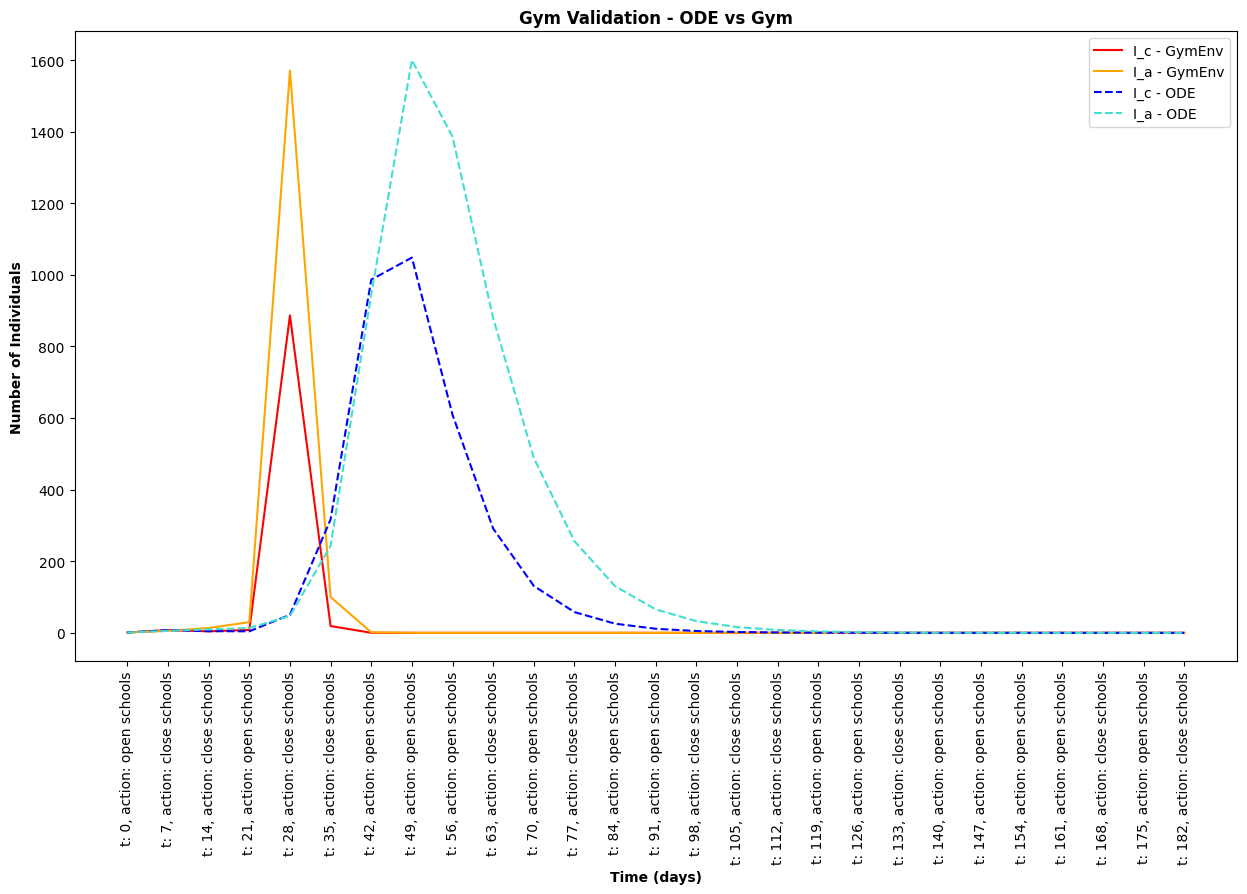

In [6]:
# Run the validation.
budget = 2
env = make_sir_env(
    budget,
    seeds,
    N_c,
    N_a,
    disease_params["gamma"],
    disease_params["beta"]
)
validate_gym(env, seeds, N_c, N_a, disease_params, budget)
env.close()

### **Learning an Optimal Policy with PPO**

We will use Stable Baseline’s Proximal Policy Optimization (PPO) implementation to learn an optimal policy for different budgets. Implement a script that instantiates your gym environment and initializes a PPO agent to learn a policy. Develop this script such that you can parameterize it for different school closure budgets and different PPO seeds. You can use inspiration from the Jupyter notebook where PPO was used with the LunarLander environment.

**Some Important Tips**

- For PPO, we only adjust the learning rate hyperparameter, which we recommend setting to `2e-4`. This was hand-tuned (we will get back to that later today).
- To learn efficiently in this environment, it is advised to normalize the observation space (why do you think this is the case?) and reward function. This can be done by wrapping your environment (i.e., `NormalizeObservation` and `NormalizeReward` in the `gymnasium.wrappers` module).
- Stable Baselines allows you to write TensorBoard logs, which make it easy to inspect your learning curves. Look for the `tb_log_name` parameter to add the budget to your TensorBoard run names.

**Experiments**

With this script, run some experiments (35,000 steps should be enough to learn something) with:

- `budget = {2, 4, 8}`
- Two different random seeds

We provide functions to visualize the learned policy. Visualize these results through TensorBoard and interpret the findings.

In [7]:
def print_sequence(env: gym.Env, model: PPO, budget: int) -> list:
    """
    Print and return the sequence of actions taken by the model.

    Arguments
    ---------
    env    :  The Gym environment.
    model  :  The trained PPO model.
    budget :  The number of weeks schools can be closed.

    Returns
    -------
    action_sequence :  A list indicating whether schools were closed each week.

    """
    action_sequence = []
    observation, _ = env.reset()

    step = 0
    done = False
    used_budget = 0

    while not done:
        action, _ = model.predict(observation, deterministic=True)
        close_schools = (action == 1)

        if used_budget >= budget:
            close_schools = False

        if close_schools:
            used_budget += 1

        action_sequence.append(close_schools)
        observation, _, terminated, _, _ = env.step(action)
        done = terminated
        step += 1

    print("Action sequence: ", action_sequence)
    return action_sequence


def plot_policy_with_trajectories(env: gym.Env, model: PPO, budget: int, ppo_seed: int) -> None:
    """
    Plot the infection trajectories over time with actions taken by the policy.

    Arguments
    ---------
    env      :  The Gym environment.
    model    :  The trained PPO model.
    budget   :  The number of weeks schools can be closed.
    ppo_seed :  The random seed used for reproducibility.

    Returns
    -------
    None

    """
    observation, _ = env.reset()
    actions = []
    states = []
    timesteps = []

    done = False
    step = 0
    used_budget = 0

    while not done:
        action, _ = model.predict(observation, deterministic=True)
        close_schools = (action == 1)

        if used_budget >= budget:
            close_schools = False

        if close_schools:
            used_budget += 1

        actions.append(close_schools)
        states.append((env.unwrapped.model_state[1], env.unwrapped.model_state[4]))  # I_c, I_a
        timesteps.append(step * 7)

        observation, _, terminated, _, _ = env.step(action)
        done = terminated
        step += 1

    plt.figure(figsize=(15, 10))

    c_data = [state[0] for state in states]
    a_data = [state[1] for state in states]

    plt.plot(timesteps, c_data, label="Inf. Children", color='red')
    plt.plot(timesteps, a_data, label="Inf. Adults", color='blue')

    plt.subplots_adjust(bottom=0.25)
    xlabels = [
        f"t: {t}, action: {'close schools' if action else 'open schools'}"
        for t, action in zip(timesteps, actions)
    ]
    plt.xticks(timesteps, xlabels, rotation=90)

    plt.xlabel("Time (days)", fontweight='bold')
    plt.ylabel("Number of Individuals", fontweight='bold')
    plt.title(f"PPO: Actions Taken – Budget {budget}", fontweight='bold')
    plt.legend()

    import os
    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/ppo_results_budget_{budget}_seed_{ppo_seed}.png", dpi=300)


Running PPO with budget = 2 (Run 1/2)

PPO with budget = 2, seed = 537458
Mean Reward: -3.24, Std Reward: 0.00
Action sequence:  [True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]

Running PPO with budget = 2 (Run 2/2)

PPO with budget = 2, seed = 36007
Mean Reward: -3.24, Std Reward: 0.00
Action sequence:  [True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]

Running PPO with budget = 4 (Run 1/2)

PPO with budget = 4, seed = 588831
Mean Reward: -3.03, Std Reward: 0.00
Action sequence:  [False, False, True, True, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]

Running PPO with budget = 4 (Run 2/2)

PPO with budget = 4, seed = 95

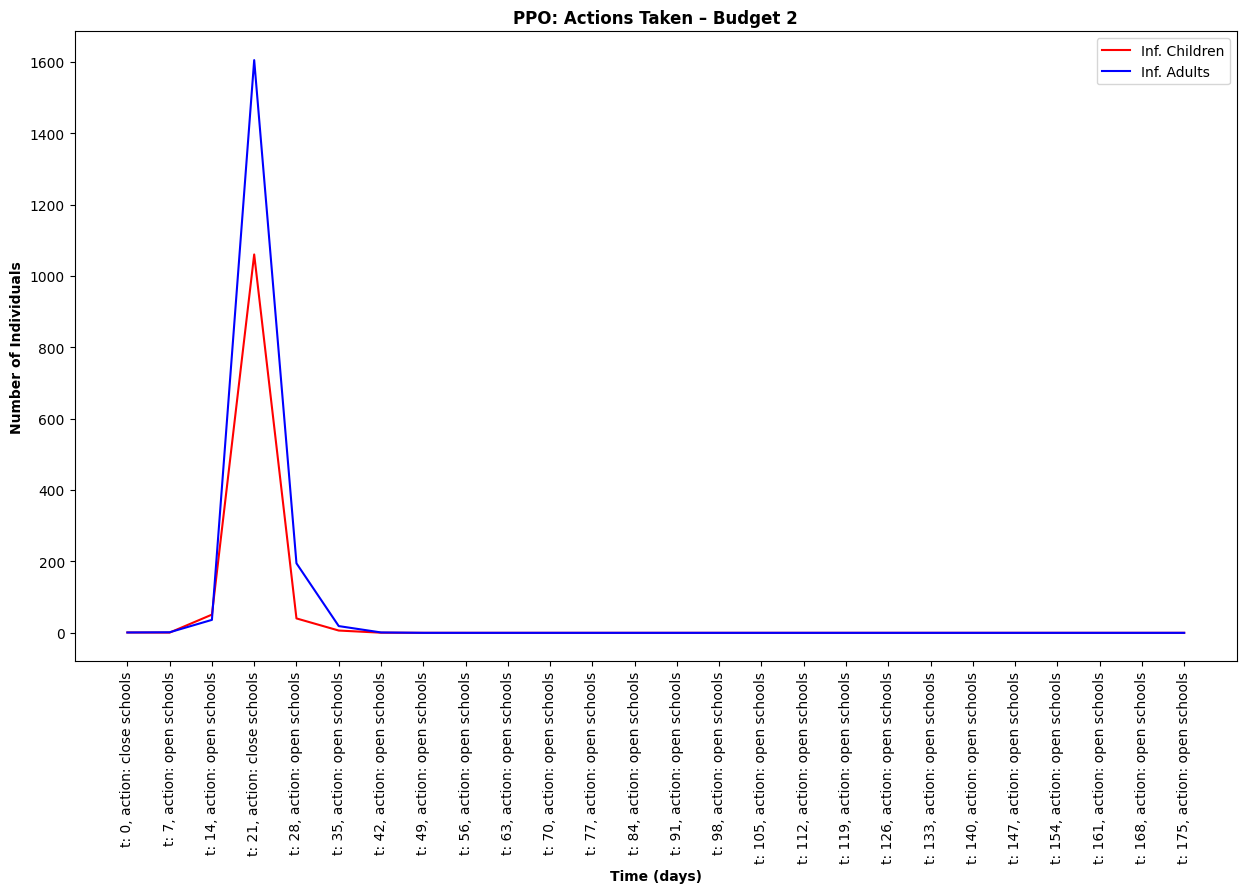

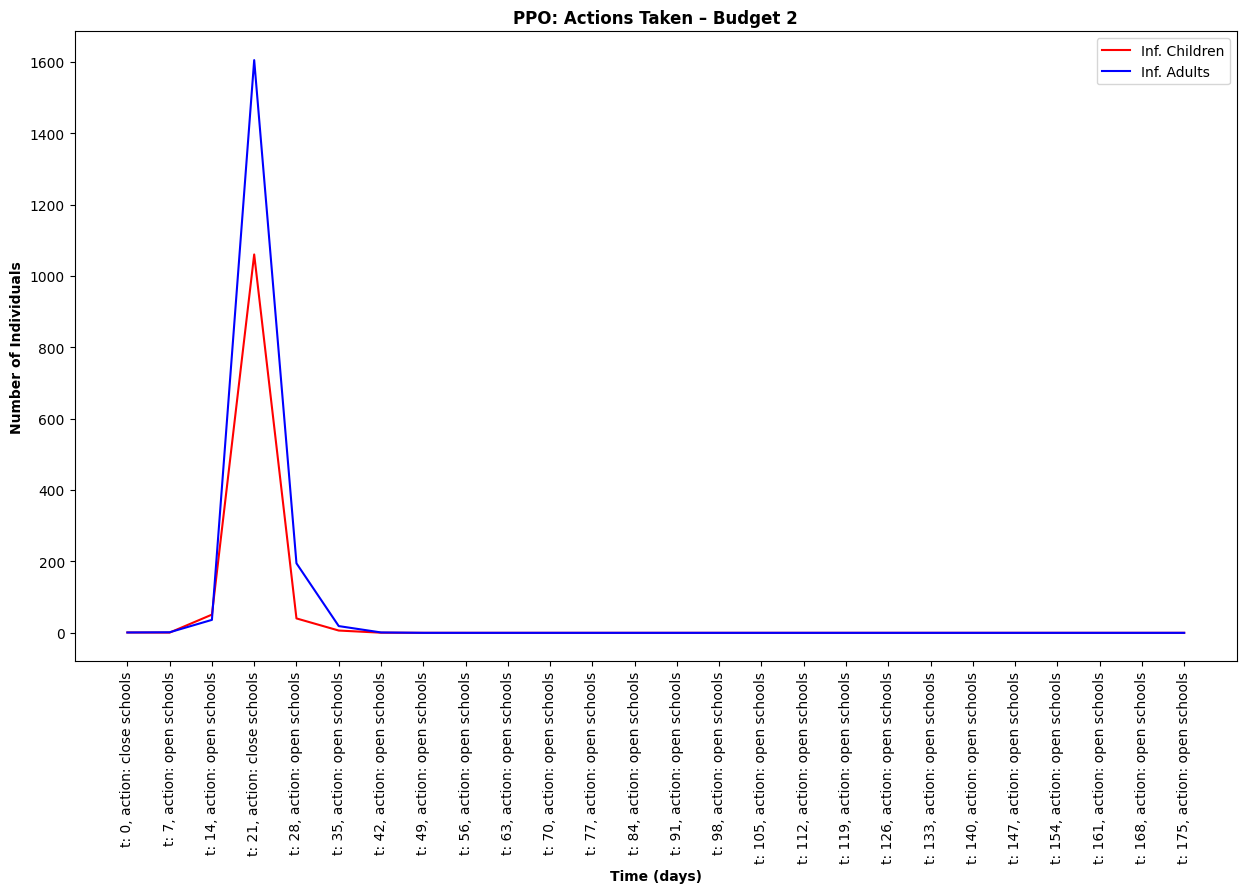

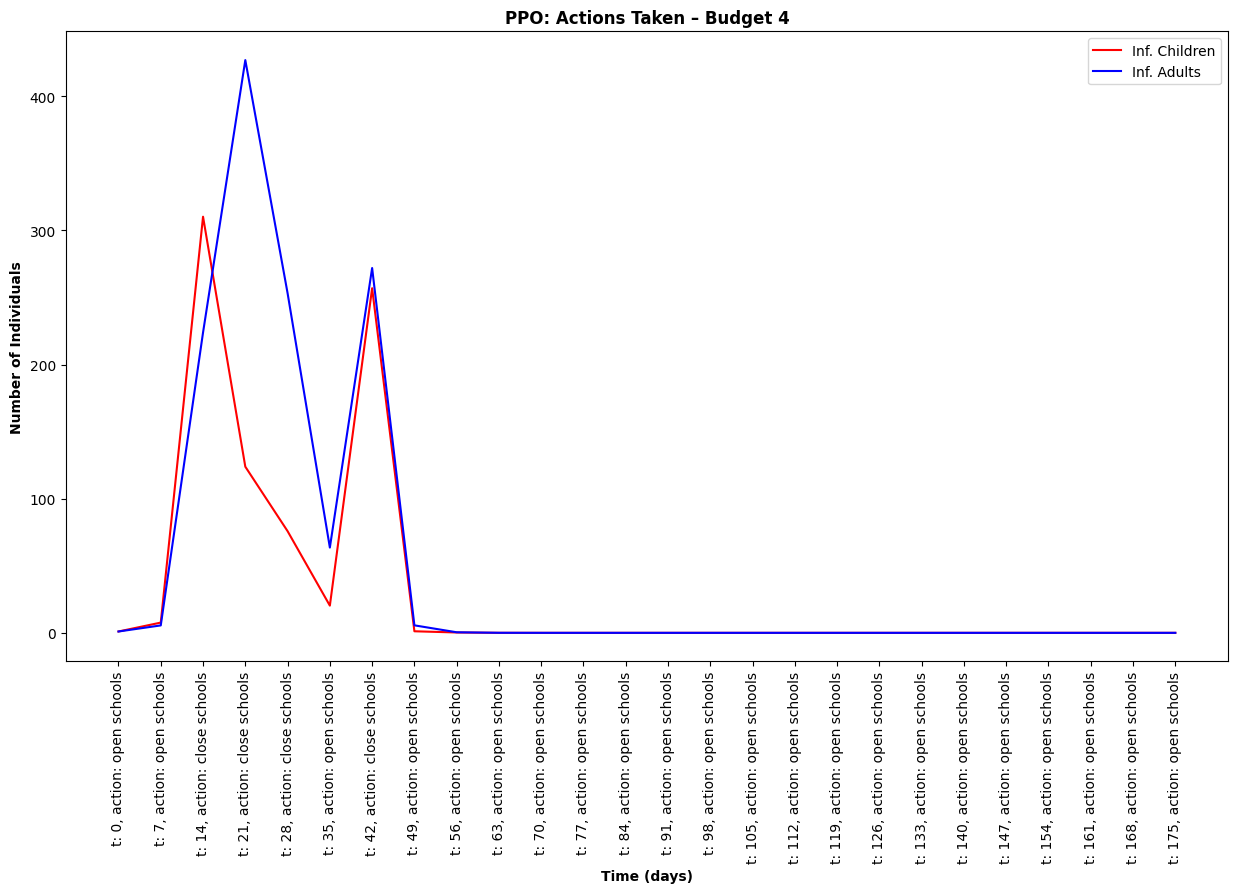

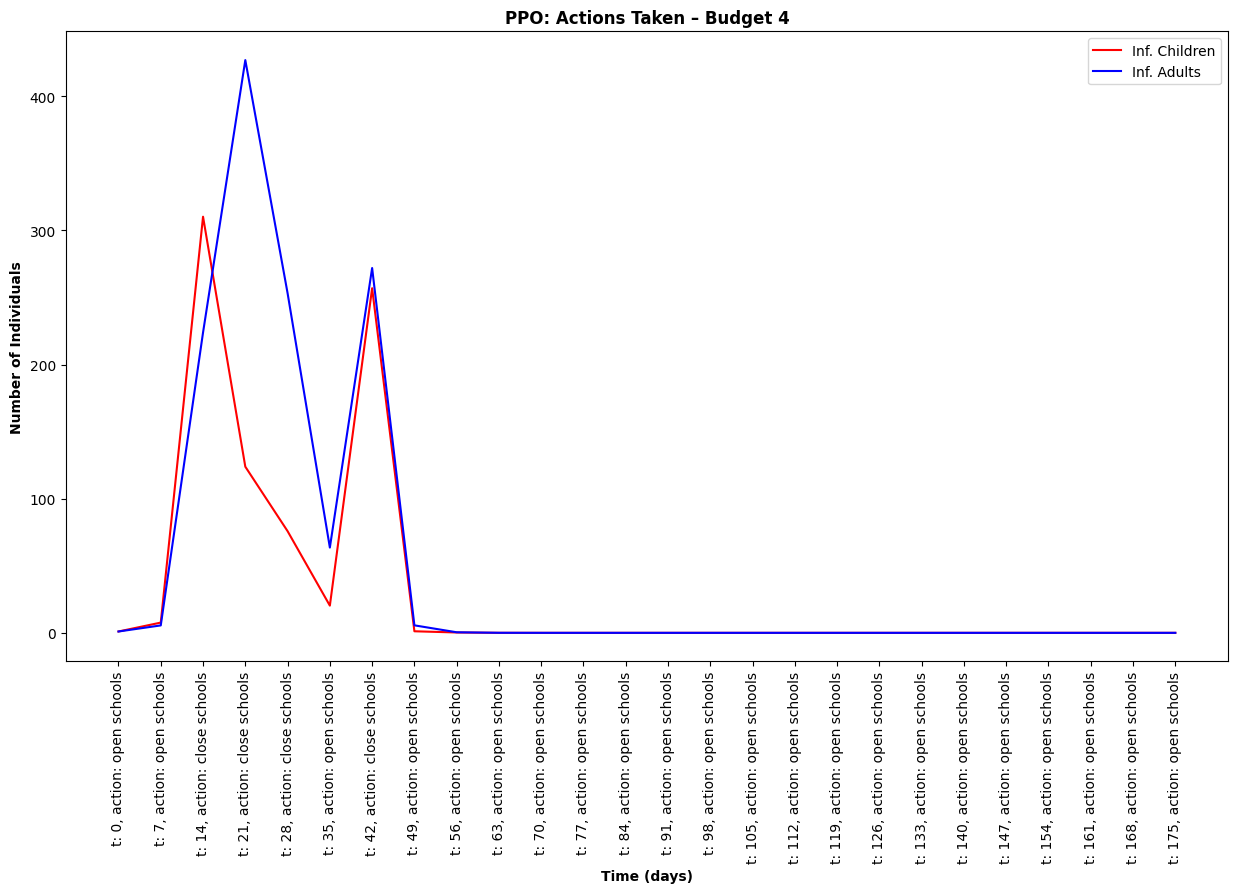

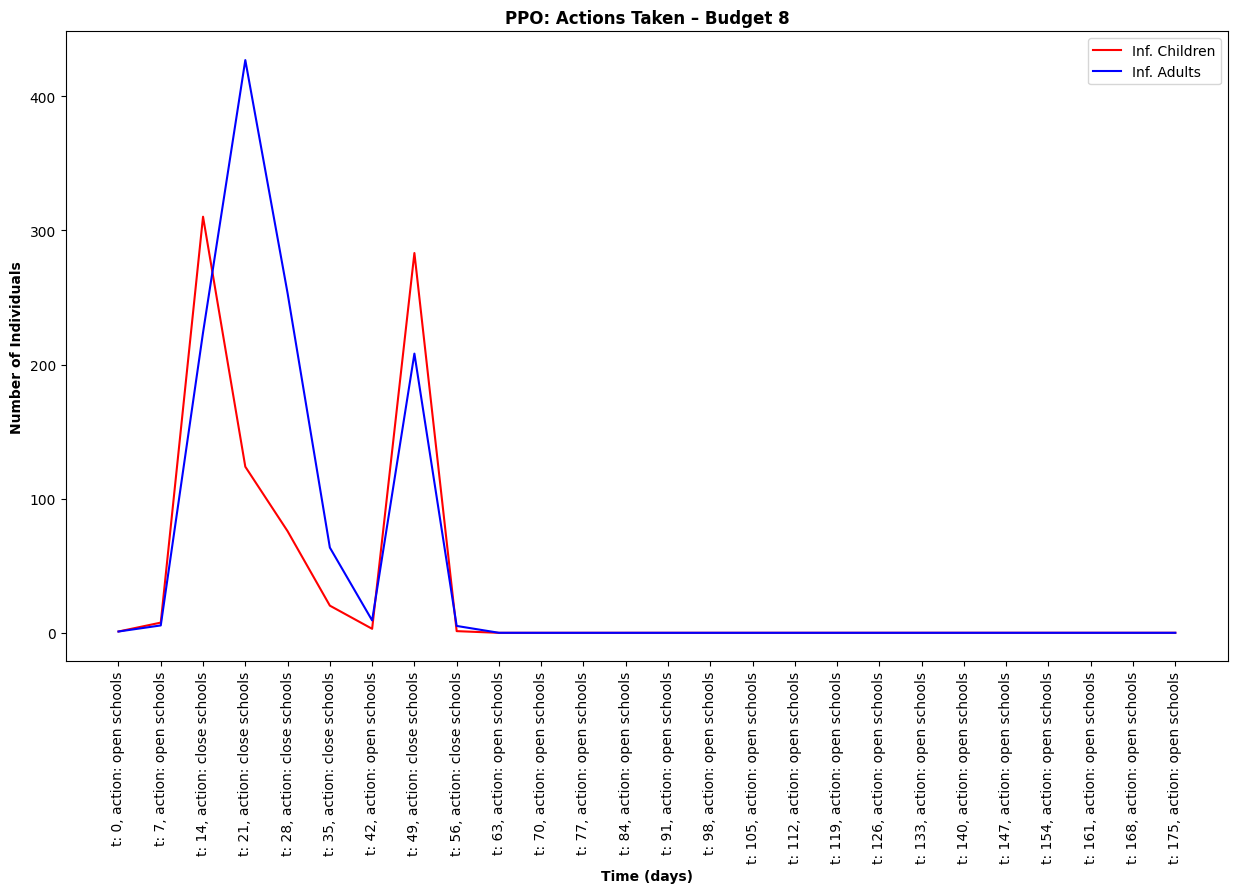

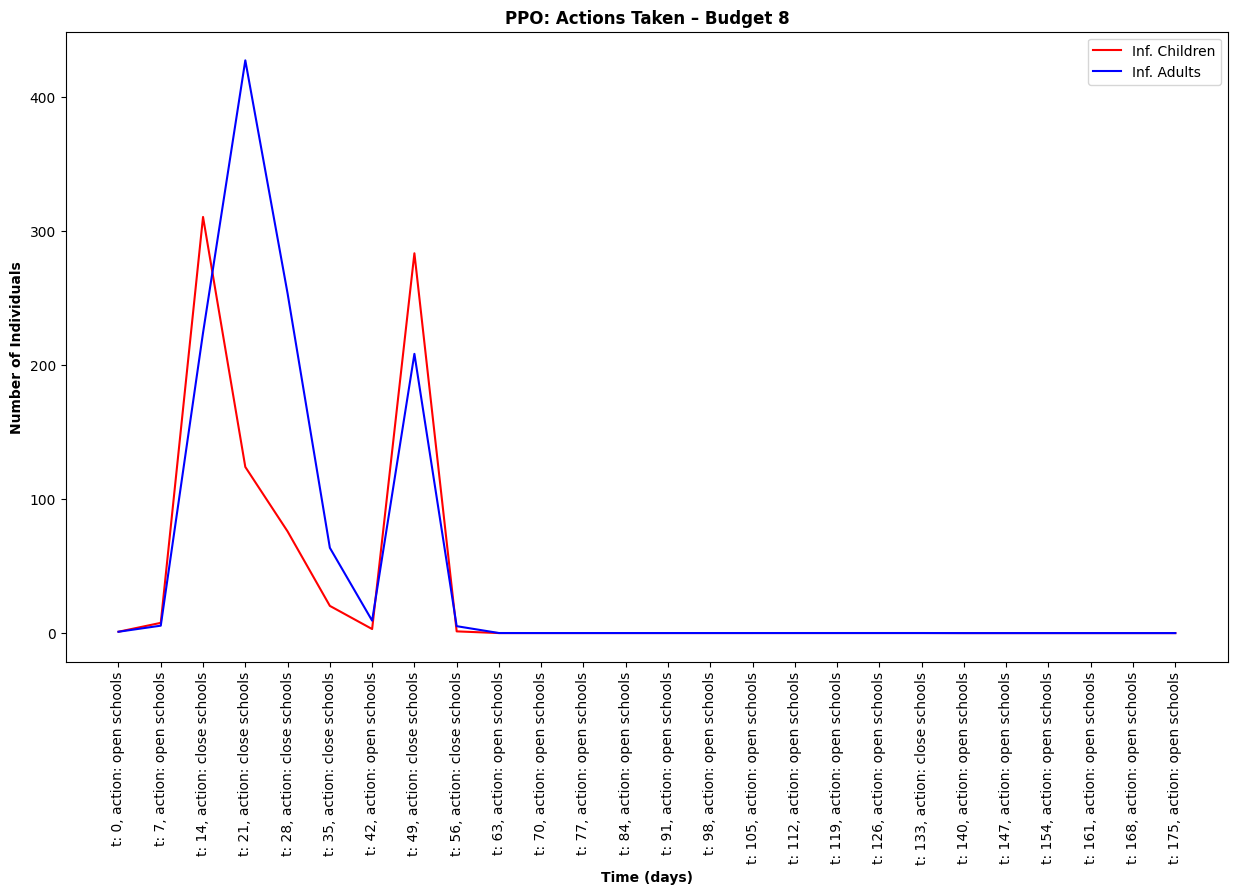

In [8]:
from random import seed


for budget in [2, 4, 8]:
    for seed_idx in range(2):
        print(f"\n{'='*50}")
        print(f"Running PPO with budget = {budget} (Run {seed_idx + 1}/2)")
        print(f"{'='*50}\n")
        
        # Create the Gym environment to learn the policy.
        env = make_sir_env(
            budget=budget,
            seeds=seeds,
            N_c=N_c,
            N_a=N_a,
            gamma=disease_params["gamma"],
            beta=disease_params["beta"]
        )

        # Normalize observations and rewards.
        env = NormalizeObservation(env)
        env = NormalizeReward(env)

        # Initialize the PPO model with logging.
        ppo_seed = np.random.randint(0, 1_000_000)
        ppo_model = PPO(
            policy="MlpPolicy",
            env=env,
    learning_rate=2e-4,
            verbose=0,  # Turned off verbose to keep output clean
            seed=ppo_seed,
            tensorboard_log="tensorboard_log"
        )

        # Train the policy.
        ppo_model.learn(
    total_timesteps=35_000,
            tb_log_name=f"ppo_budget_{budget}/seed_{ppo_seed}"
        )

        # Evaluate the trained policy.
        mean_reward, std_reward = evaluate_policy(
            model=ppo_model,
            env=env,
            deterministic=True
        )

        print(f"PPO with budget = {budget}, seed = {ppo_seed}")
        print(f"Mean Reward: {mean_reward:.2f}, Std Reward: {std_reward:.2f}")

        # Display the learned policy sequence.
        print_sequence(env, ppo_model, budget)

        # Visualize the policy and corresponding infection trajectories.
        plot_policy_with_trajectories(env, ppo_model, budget, ppo_seed)

        # Close the environment.
        env.close()


### **References**
- [1] https://arxiv.org/pdf/2003.13676
- [2] https://www.gymlibrary.dev/content/environment_creation/
- [3] https://stable-baselines.readthedocs.io/en/master/guide/tensorboard.html
